# **TEMPLATE** <br>
 **Federated InceptionV3 Image Multiclassifier for Custom Dataset**


```
📌 Don't forget to create a COPY before experimenting wtih anything....
```



## **FedCNN Custom Image Multicalssifier**

#### Dependancies & Constants

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Precision, Recall, Accuracy
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [2]:
# Define constants
BATCH_SIZE = 64
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
NUM_CLIENTS = 3 # min must be 2
IMG_SIZE = (75, 75) # Fall Dataset original shape(225,225).
DEBUG = False

### **Loading Custom Multiclass Dataset**

In [3]:
# Loading Custom Data
# Define the path to the directory containing the image data
data_dir = 'F:/Plabon/Dataset2'

# Use the image_dataset_from_directory method to load and preprocess the data
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # split 20% of data for validation
    subset='training',
    seed=42, # set a random seed for reproducibility
    image_size= IMG_SIZE,
    batch_size= None
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size= IMG_SIZE,
    batch_size= None
)

Found 47000 files belonging to 47 classes.
Using 37600 files for training.
Found 47000 files belonging to 47 classes.
Using 9400 files for validation.


#### Spliting Custom Dataset

In [4]:
# Get the class names
class_names = train_dataset.class_names

# # Configure the dataset for performance
# train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
# val_dataset = test_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Extract all the images and labels from the dataset( and also Split the datasets into X and y sets)
x_train = []
y_train = []
for batch in train_dataset:
    batch_images, batch_labels = batch
    x_train.append(batch_images.numpy())
    y_train.append(batch_labels.numpy())

x_train = np.concatenate([np.expand_dims(i,axis=0) for i in x_train])
y_train = np.concatenate([np.expand_dims(i,axis=0) for i in y_train])

x_test = []
y_test = []
for batch in test_dataset:
    batch_images, batch_labels = batch
    x_test.append(batch_images.numpy())
    y_test.append(batch_labels.numpy())

x_test = np.concatenate([np.expand_dims(i,axis=0) for i in x_test])
y_test = np.concatenate([np.expand_dims(i,axis=0) for i in y_test])

In [5]:
# Preprocessing
x_train /= 255
x_test /= 255
y_train = to_categorical(y_train, len(class_names))
y_test = to_categorical(y_test, len(class_names))

In [6]:
x_train.shape

(37600, 75, 75, 3)

In [8]:
x_test.shape

(9400, 75, 75, 3)

In [9]:
print(class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '5', '6', '7', '8', '9']


### **Model**

In [10]:
# Define CNN architecture and compile model
def create_inceptionv3_model(model_type="GLOBAL"):
    print(f'........................ creating Inceptionv3 model : {model_type}')
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(len(class_names), activation='softmax')(x)  # Update the number of classes
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Optional: Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False

    adam = Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
    return model

In [11]:
global_model = create_inceptionv3_model()
global_acc_list = []
global_loss_list = []

........................ creating Inceptionv3 model : GLOBAL


In [12]:
global_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 75, 75, 3)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 37, 37, 32)           864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 37, 37, 32)           96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 37, 37, 32)           0         ['batch_normalization[0][0

### **Model Visualization**

In [13]:
# Sequential model in Keras -> ASCII
graphics = {
    "Convolution2D": " \|/ ",
    "Activation": "|||||",
    "Flatten": "|||||",
    "MaxPooling2D": "YYYYY",
    "Dropout": " | ||",
    "Dense": "XXXXX",
    "ZeroPadding2D": "\|||/"
}

def jsonize(model):
    res = []
    for layer in model.layers:
        x = {}
        
        x["name"] = layer.name
        x["kind"] = layer.__class__.__name__
        x["input_shape"] = layer.input_shape[1:]
        x["output_shape"] = layer.output_shape[1:]
        x["n_parameters"] =  layer.count_params()
        try:
            x["activation"] = layer.activation.__name__ 
        except AttributeError:
            x["activation"] = ""
        
        res.append(x)
    return res

def compress_layers(jsonized_layers):
    res = [jsonized_layers[0]]
    for each in jsonized_layers[1:]:
        if each["kind"] == "Activation" and res[-1]["activation"] in ["", "linear"]:
            res[-1]["activation"] = each["activation"]
        else:
            res.append(each)
    return res

# data_template = "{activation:>15s}   #####   {shape} = {length}"
data_template = "{activation:>15s}   #####   {shape}"
layer_template = "{kind:>15s}   {graphics} -------------------{n_parameters:10d}   {percent_parameters:5.1f}%"

def product(iterable):
    res = 1
    for each in iterable:
        res *= each
    return res

def print_layers(jsonized_layers, sparser=False, simplify=False, header=True):
    
    if simplify:
        jsonized_layers = compress_layers(jsonized_layers)
    
    all_weights = sum([each["n_parameters"] for each in jsonized_layers])
    
    if header:
        print("      OPERATION           DATA DIMENSIONS   WEIGHTS(N)   WEIGHTS(%)\n")
    
    print(data_template.format(
            activation="Input",
            shape=jsonized_layers[0]["input_shape"],
            # length=product(jsonized_layers[0]["output_shape"])
    ))
    
    for each in jsonized_layers:
        
        if sparser:
            print("")
            
        print(layer_template.format(
                kind=each["kind"] if each["kind"] != "Activation" else "",
                graphics=graphics.get(each["kind"], "?????"),
                n_parameters=each["n_parameters"],
                percent_parameters=100 * each["n_parameters"] / all_weights
        ))
        
        if sparser:
            print("")
            
        print(data_template.format(
                activation=each["activation"] if each["activation"] != "linear" else "",
                shape=each["output_shape"],
                # length=product(each["output_shape"])
        ))
        
def sequential_model_to_ascii_printout(model, sparser=False, simplify=True, header=True):
    print_layers(jsonize(model), sparser=sparser, simplify=simplify, header=header)

In [14]:
sequential_model_to_ascii_printout(global_model)

      OPERATION           DATA DIMENSIONS   WEIGHTS(N)   WEIGHTS(%)

          Input   #####   []
     InputLayer   ????? -------------------         0     0.0%
                  #####   []
         Conv2D   ????? -------------------       864     0.0%
                  #####   (37, 37, 32)
BatchNormalization   ????? -------------------        96     0.0%
           relu   #####   (37, 37, 32)
         Conv2D   ????? -------------------      9216     0.0%
                  #####   (35, 35, 32)
BatchNormalization   ????? -------------------        96     0.0%
           relu   #####   (35, 35, 32)
         Conv2D   ????? -------------------     18432     0.1%
                  #####   (35, 35, 64)
BatchNormalization   ????? -------------------       192     0.0%
           relu   #####   (35, 35, 64)
   MaxPooling2D   YYYYY -------------------         0     0.0%
                  #####   (17, 17, 64)
         Conv2D   ????? -------------------      5120     0.0%
                  ##### 

In [15]:
# Plot model in Keras
from tensorflow.keras.utils import plot_model

In [16]:
plot_model(global_model, to_file='cnn_model.png', show_shapes=True, show_layer_activations=True, show_dtype=False, show_layer_names=True)

### **Federated Training**

In [17]:
%%time

# Federated learning loop
for epoch in range(NUM_EPOCHS):
    print(f'[EPOCH #{epoch+1}] ------------------------ running epochs {epoch+1}')
    # Create a copy of the global model for each client
    client_models = []
    for i in range(NUM_CLIENTS):
        client_model = create_inceptionv3_model(f"CLIENT[{i+1}]")
        client_model.set_weights(global_model.get_weights())
        client_models.append(client_model)
    
    # Train each client model on its own data
    for i in range(NUM_CLIENTS):
        # 

        print(f'[CLIENT #{i+1}] ....................... training begins...')
        start = i * (len(x_train) // NUM_CLIENTS)
        end = (i+1) * (len(x_train) // NUM_CLIENTS)
        if DEBUG is True:
          print(f"[DEBUG] ################################## Client[{i+1}] - Training on x_train[{start}]:x_train[{end}]")
        x_train_i = x_train[start:end]
        y_train_i = y_train[start:end]
        
        # Local optimization on client model
        Optimizer = Adam(learning_rate=LEARNING_RATE)
        client_models[i].compile(optimizer=Optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
        # after Applying Local optimization not fit the local model
        client_models[i].fit(x_train_i, y_train_i, batch_size=BATCH_SIZE, epochs=1, verbose=1)
    
    # Average the weights of the client models to update the global model
    print(f'Averaging Begins for EPOCH #{epoch + 1}')
    average_weights = []
    for j in range(len(global_model.get_weights())):
        layer_weights = np.array([client_models[i].get_weights()[j] for i in range(NUM_CLIENTS)])
        average_layer_weights = np.mean(layer_weights, axis=0)
        average_weights.append(average_layer_weights)
    global_model.set_weights(average_weights)
    
    # Evaluate the global model
    loss, acc = global_model.evaluate(x_test, y_test, verbose=0)
    global_acc_list.append(acc)
    global_loss_list.append(loss)
    print('[SUMMARY] ------------------------ Epoch #{}, Global Test Loss: {}, Global Test Accuracy: {}\n'.format(epoch+1, loss, acc))

[EPOCH #1] ------------------------ running epochs 1
........................ creating Inceptionv3 model : CLIENT[1]
........................ creating Inceptionv3 model : CLIENT[2]
........................ creating Inceptionv3 model : CLIENT[3]
[CLIENT #1] ....................... training begins...
196/196 [==============================] - 42s 185ms/step - loss: 3.4225 - accuracy: 0.1290
[CLIENT #2] ....................... training begins...
196/196 [==============================] - 41s 181ms/step - loss: 3.4240 - accuracy: 0.1261
[CLIENT #3] ....................... training begins...
196/196 [==============================] - 36s 153ms/step - loss: 3.4195 - accuracy: 0.1246
Averaging Begins for EPOCH #1
[SUMMARY] ------------------------ Epoch #1, Global Test Loss: 2.9530863761901855, Global Test Accuracy: 0.29457446932792664

[EPOCH #2] ------------------------ running epochs 2
........................ creating Inceptionv3 model : CLIENT[1]
........................ creating Incepti

In [18]:
global_model.save('inceptionv3-e10.h5')

C:\Users\USER\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


#### Metrics

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Train set
y_train_pred = global_model.predict(x_train)
y_train_pred = np.argmax(y_train_pred, axis=1)
y_train_true = np.argmax(y_train, axis=1)

# Test set
y_pred = global_model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Metrix
cm = confusion_matrix(y_true, y_pred)
cm_train = confusion_matrix(y_train_true, y_train_pred)

294/294 [==============================] - 34s 113ms/step


In [20]:
import re
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, digits=4)
print('test metrics: ')
print(report)

accuracy = float(re.findall(r'accuracy\s+([\d.]+)', report)[0])
precision = float(re.findall(r'weighted avg\s+([\d.]+)', report)[0])
recall = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)', report)[0][1])
f1_score = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', report)[0][2])

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-score: {f1_score:.2%}")

report = classification_report(y_train_true, y_train_pred, digits=4)
print('-----------------------')
print('train metrics: ')
print(report)

accuracy_train = float(re.findall(r'accuracy\s+([\d.]+)', report)[0])
precision_train = float(re.findall(r'weighted avg\s+([\d.]+)', report)[0])
recall_train = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)', report)[0][1])
f1_score_train = float(re.findall(r'weighted avg\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', report)[0][2])

print(f"Accuracy: {accuracy_train:.2%}")
print(f"Precision: {precision_train:.2%}")
print(f"Recall: {recall_train:.2%}")
print(f"F1-score: {f1_score_train:.2%}")


test metrics: 
              precision    recall  f1-score   support

           0     0.9721    0.8614    0.9134       202
           1     0.8698    0.8821    0.8759       212
           2     0.9303    0.9541    0.9421       196
           3     0.9899    0.9751    0.9825       201
           4     0.9536    0.9113    0.9320       203
           5     0.8818    0.9238    0.9023       210
           6     0.9524    0.8955    0.9231       201
           7     0.9593    0.9167    0.9375       180
           8     0.9188    0.9141    0.9165       198
           9     0.9029    0.9300    0.9163       200
          10     0.9050    0.9091    0.9070       220
          11     0.9469    0.9074    0.9267       216
          12     0.8579    0.8942    0.8756       189
          13     0.9397    0.9212    0.9303       203
          14     0.9372    0.9835    0.9598       182
          15     0.9023    0.9327    0.9173       208
          16     0.9038    0.9691    0.9353       194
          17

#### Visualization

In [21]:
print('For Graph Plotting\n')
print('Total EPOCHs : ', len(global_acc_list))
print('Total Clients : ', NUM_CLIENTS)
print('Global Loss list : ',global_loss_list)
print('Global Acc list : ',global_acc_list)

For Graph Plotting

Total EPOCHs :  30
Total Clients :  3
Global Loss list :  [2.9530863761901855, 1.9039677381515503, 1.450462818145752, 1.200100302696228, 1.0121556520462036, 0.8787665963172913, 0.7756677269935608, 0.7144435048103333, 0.6385977268218994, 0.5859720706939697, 0.5581130981445312, 0.519067108631134, 0.47661855816841125, 0.4601573944091797, 0.43363767862319946, 0.41901588439941406, 0.3905194401741028, 0.3779999315738678, 0.3653017282485962, 0.3495432436466217, 0.33285170793533325, 0.32947444915771484, 0.323505699634552, 0.31611135601997375, 0.3062502145767212, 0.30702129006385803, 0.2890165150165558, 0.28256821632385254, 0.27654024958610535, 0.27864864468574524]
Global Acc list :  [0.29457446932792664, 0.5394681096076965, 0.6475532054901123, 0.710106372833252, 0.7557446956634521, 0.7835106253623962, 0.8108510375022888, 0.8235106468200684, 0.8397872447967529, 0.8523404002189636, 0.8643617033958435, 0.8697872161865234, 0.8742552995681763, 0.8793616890907288, 0.8909574747085

Total EPOCHs :  30
Total Clients :  3


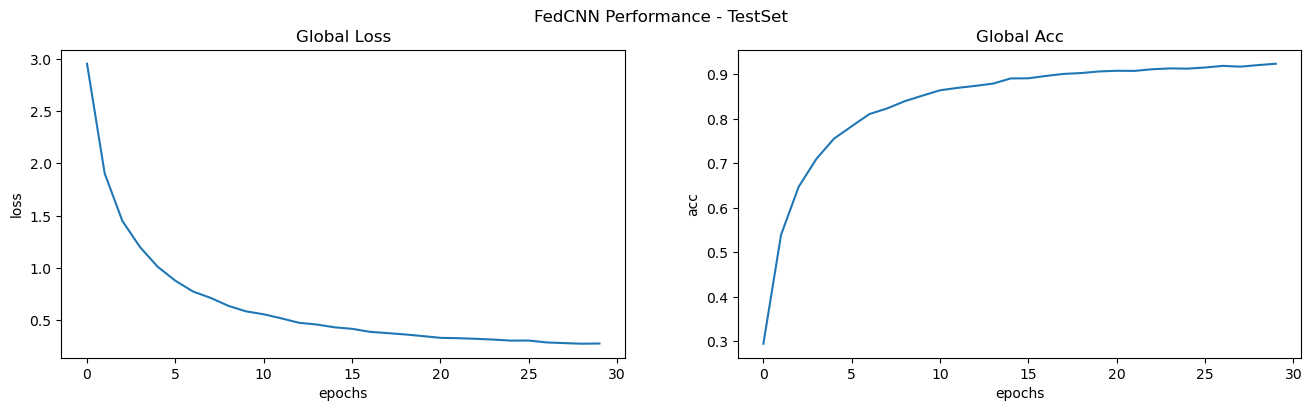

In [22]:
plt.figure(figsize=(16,4))
plt.suptitle("FedCNN Performance - TestSet")
plt.subplot(121)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.plot(list(range(0,len(global_loss_list))), global_loss_list)
plt.title("Global Loss")

plt.subplot(122)
plt.xlabel("epochs")
plt.ylabel("acc")
plt.plot(list(range(0,len(global_acc_list))), global_acc_list)
plt.title("Global Acc")

print('Total EPOCHs : ', len(global_acc_list))
print('Total Clients : ', NUM_CLIENTS)

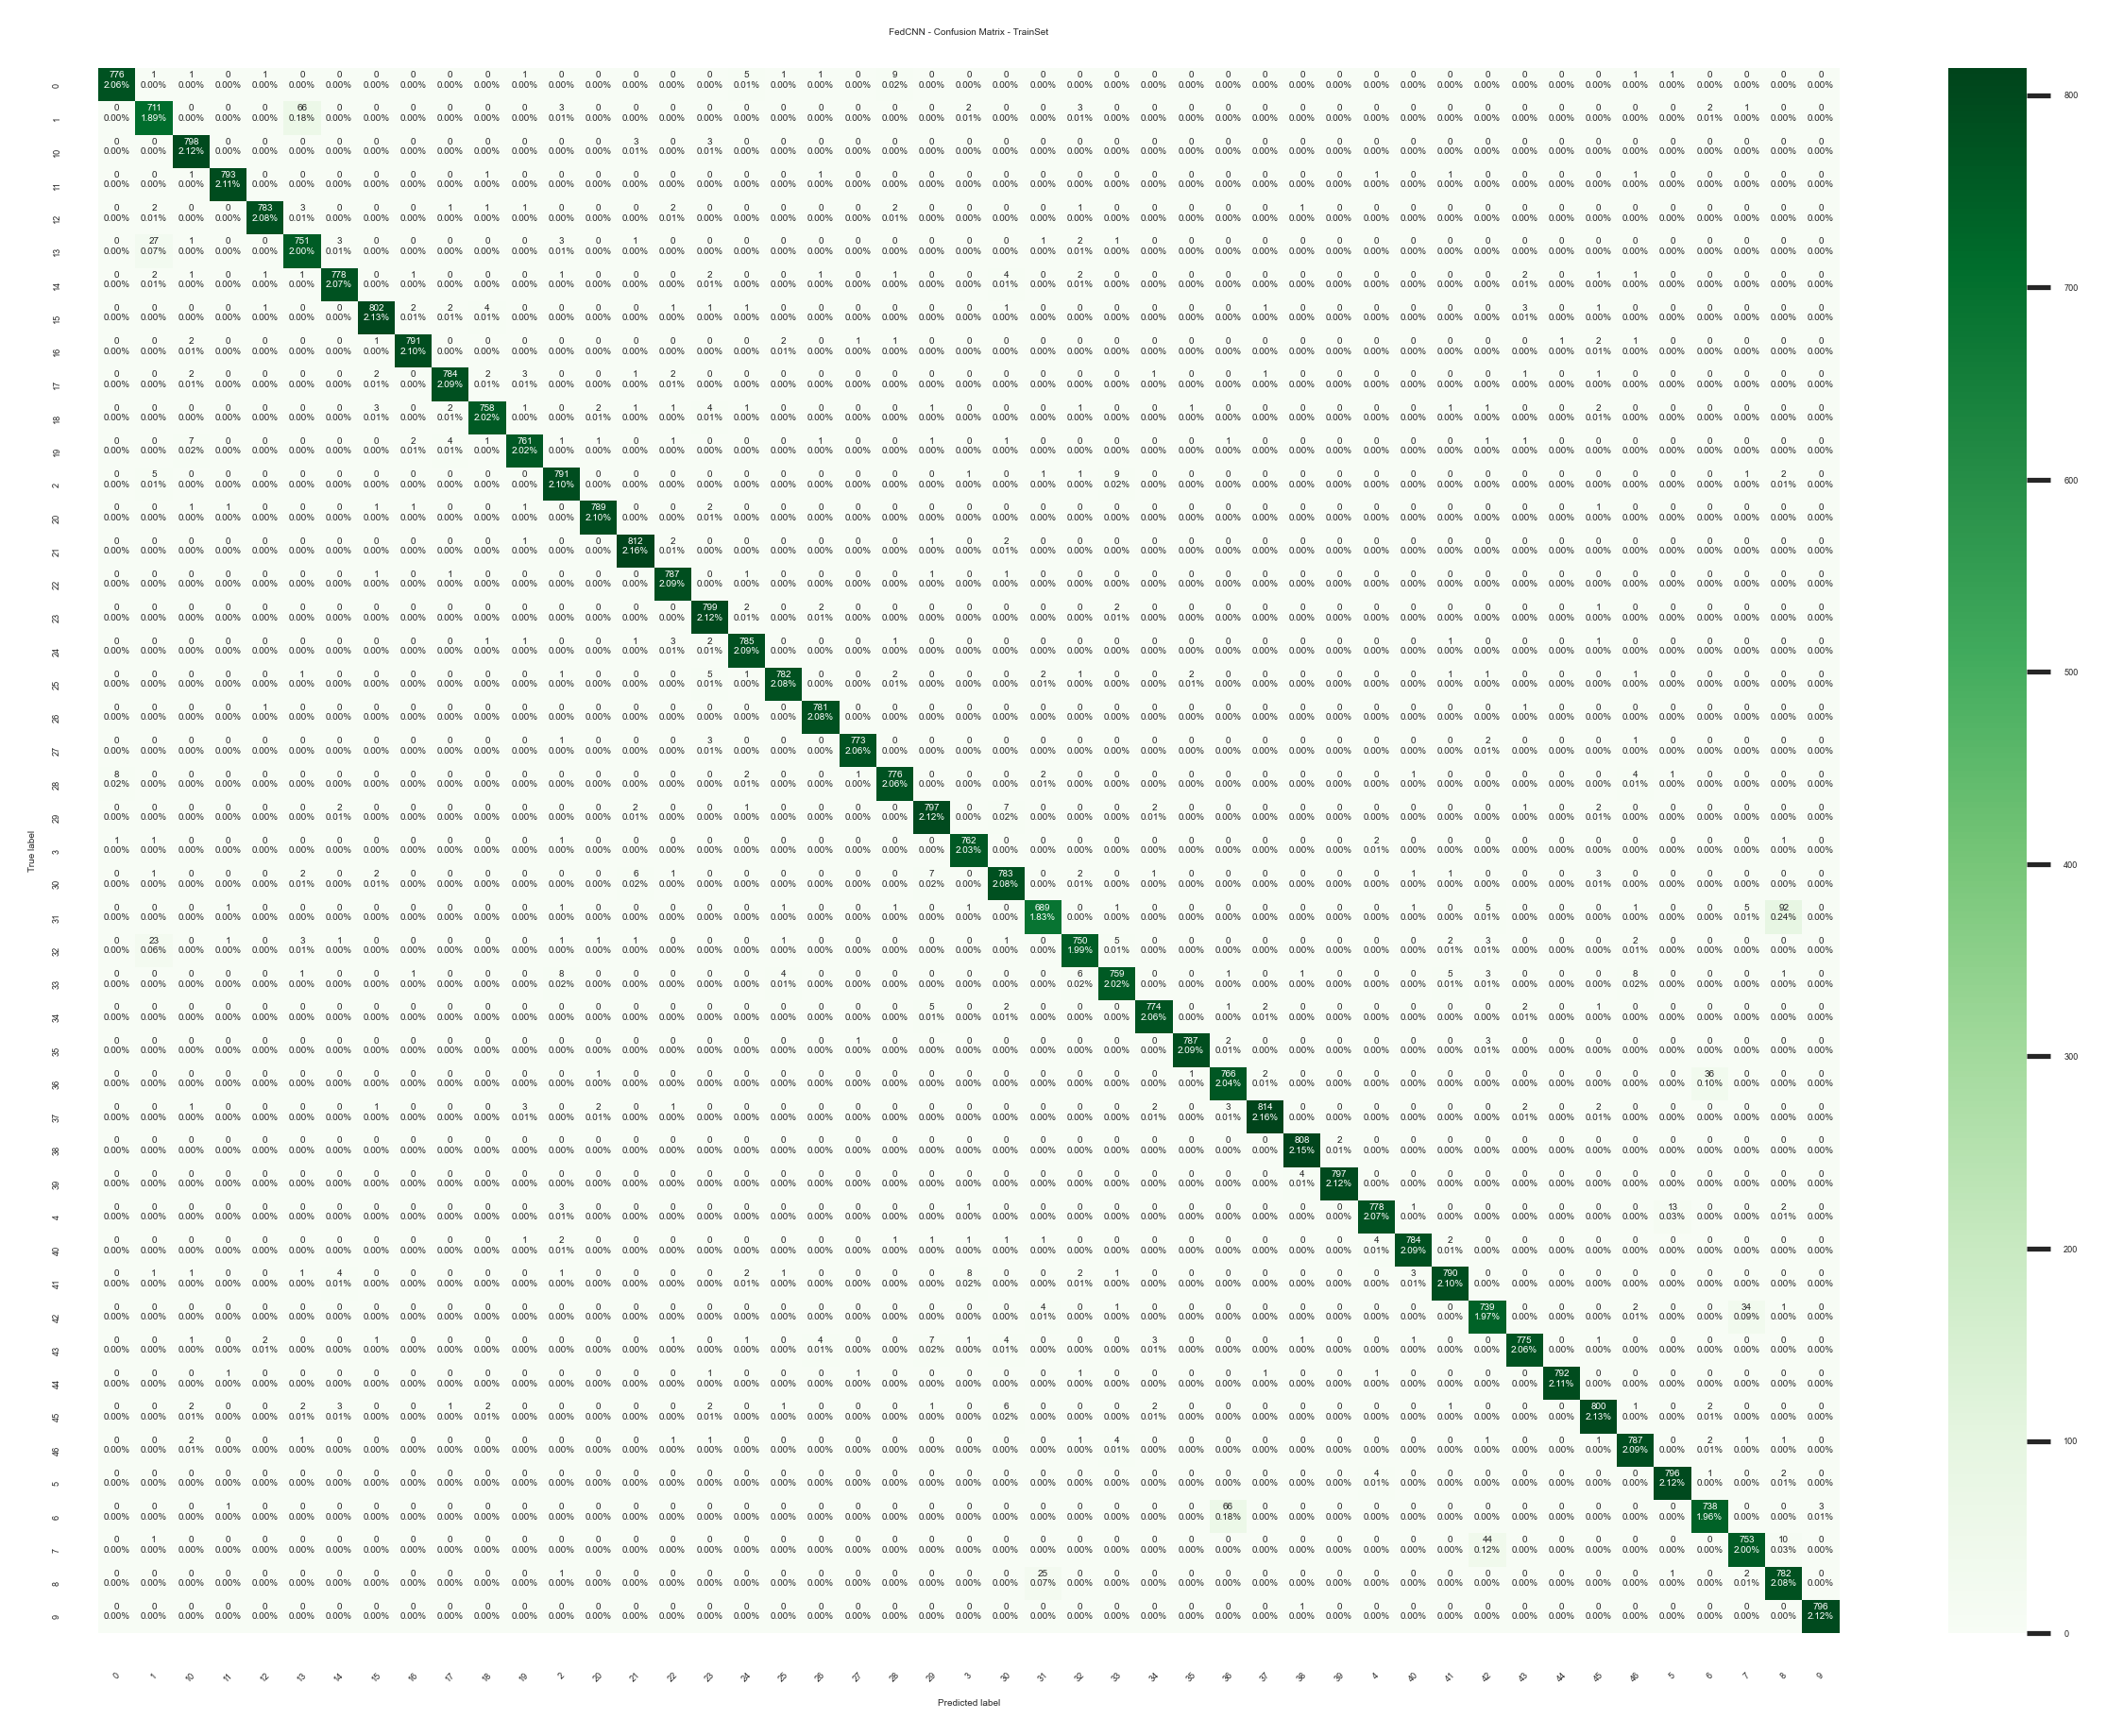

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seaborn Heatmap - Train Set
group_counts = ["{0:0.0f}".format(value) for value in cm_train.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm_train.flatten()/np.sum(cm_train)]
labels = [f"{v1}\n{v2}\n" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(cm_train.shape[0],cm_train.shape[1])
# stats_text = "\n\nAccuracy={:0.5f}\nPrecision={:0.5f}\nRecall={:0.5f}\nF1 Score={:0.5f}".format(accuracy_train, precision_train, recall_train, f1_score_train)
plt.figure(figsize=(8,6), dpi=300)
sns.set(font_scale=.2)
ax = sns.heatmap(cm_train, annot=labels, fmt='' ,xticklabels=class_names, yticklabels=class_names, cmap="Greens")
ax.tick_params(axis='x', labelrotation=45) # rotate x-axis tick labels by 45 degrees
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("FedCNN - Confusion Matrix - TrainSet\n")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix_train.pdf", dpi=300, bbox_inches='tight')
plt.show()


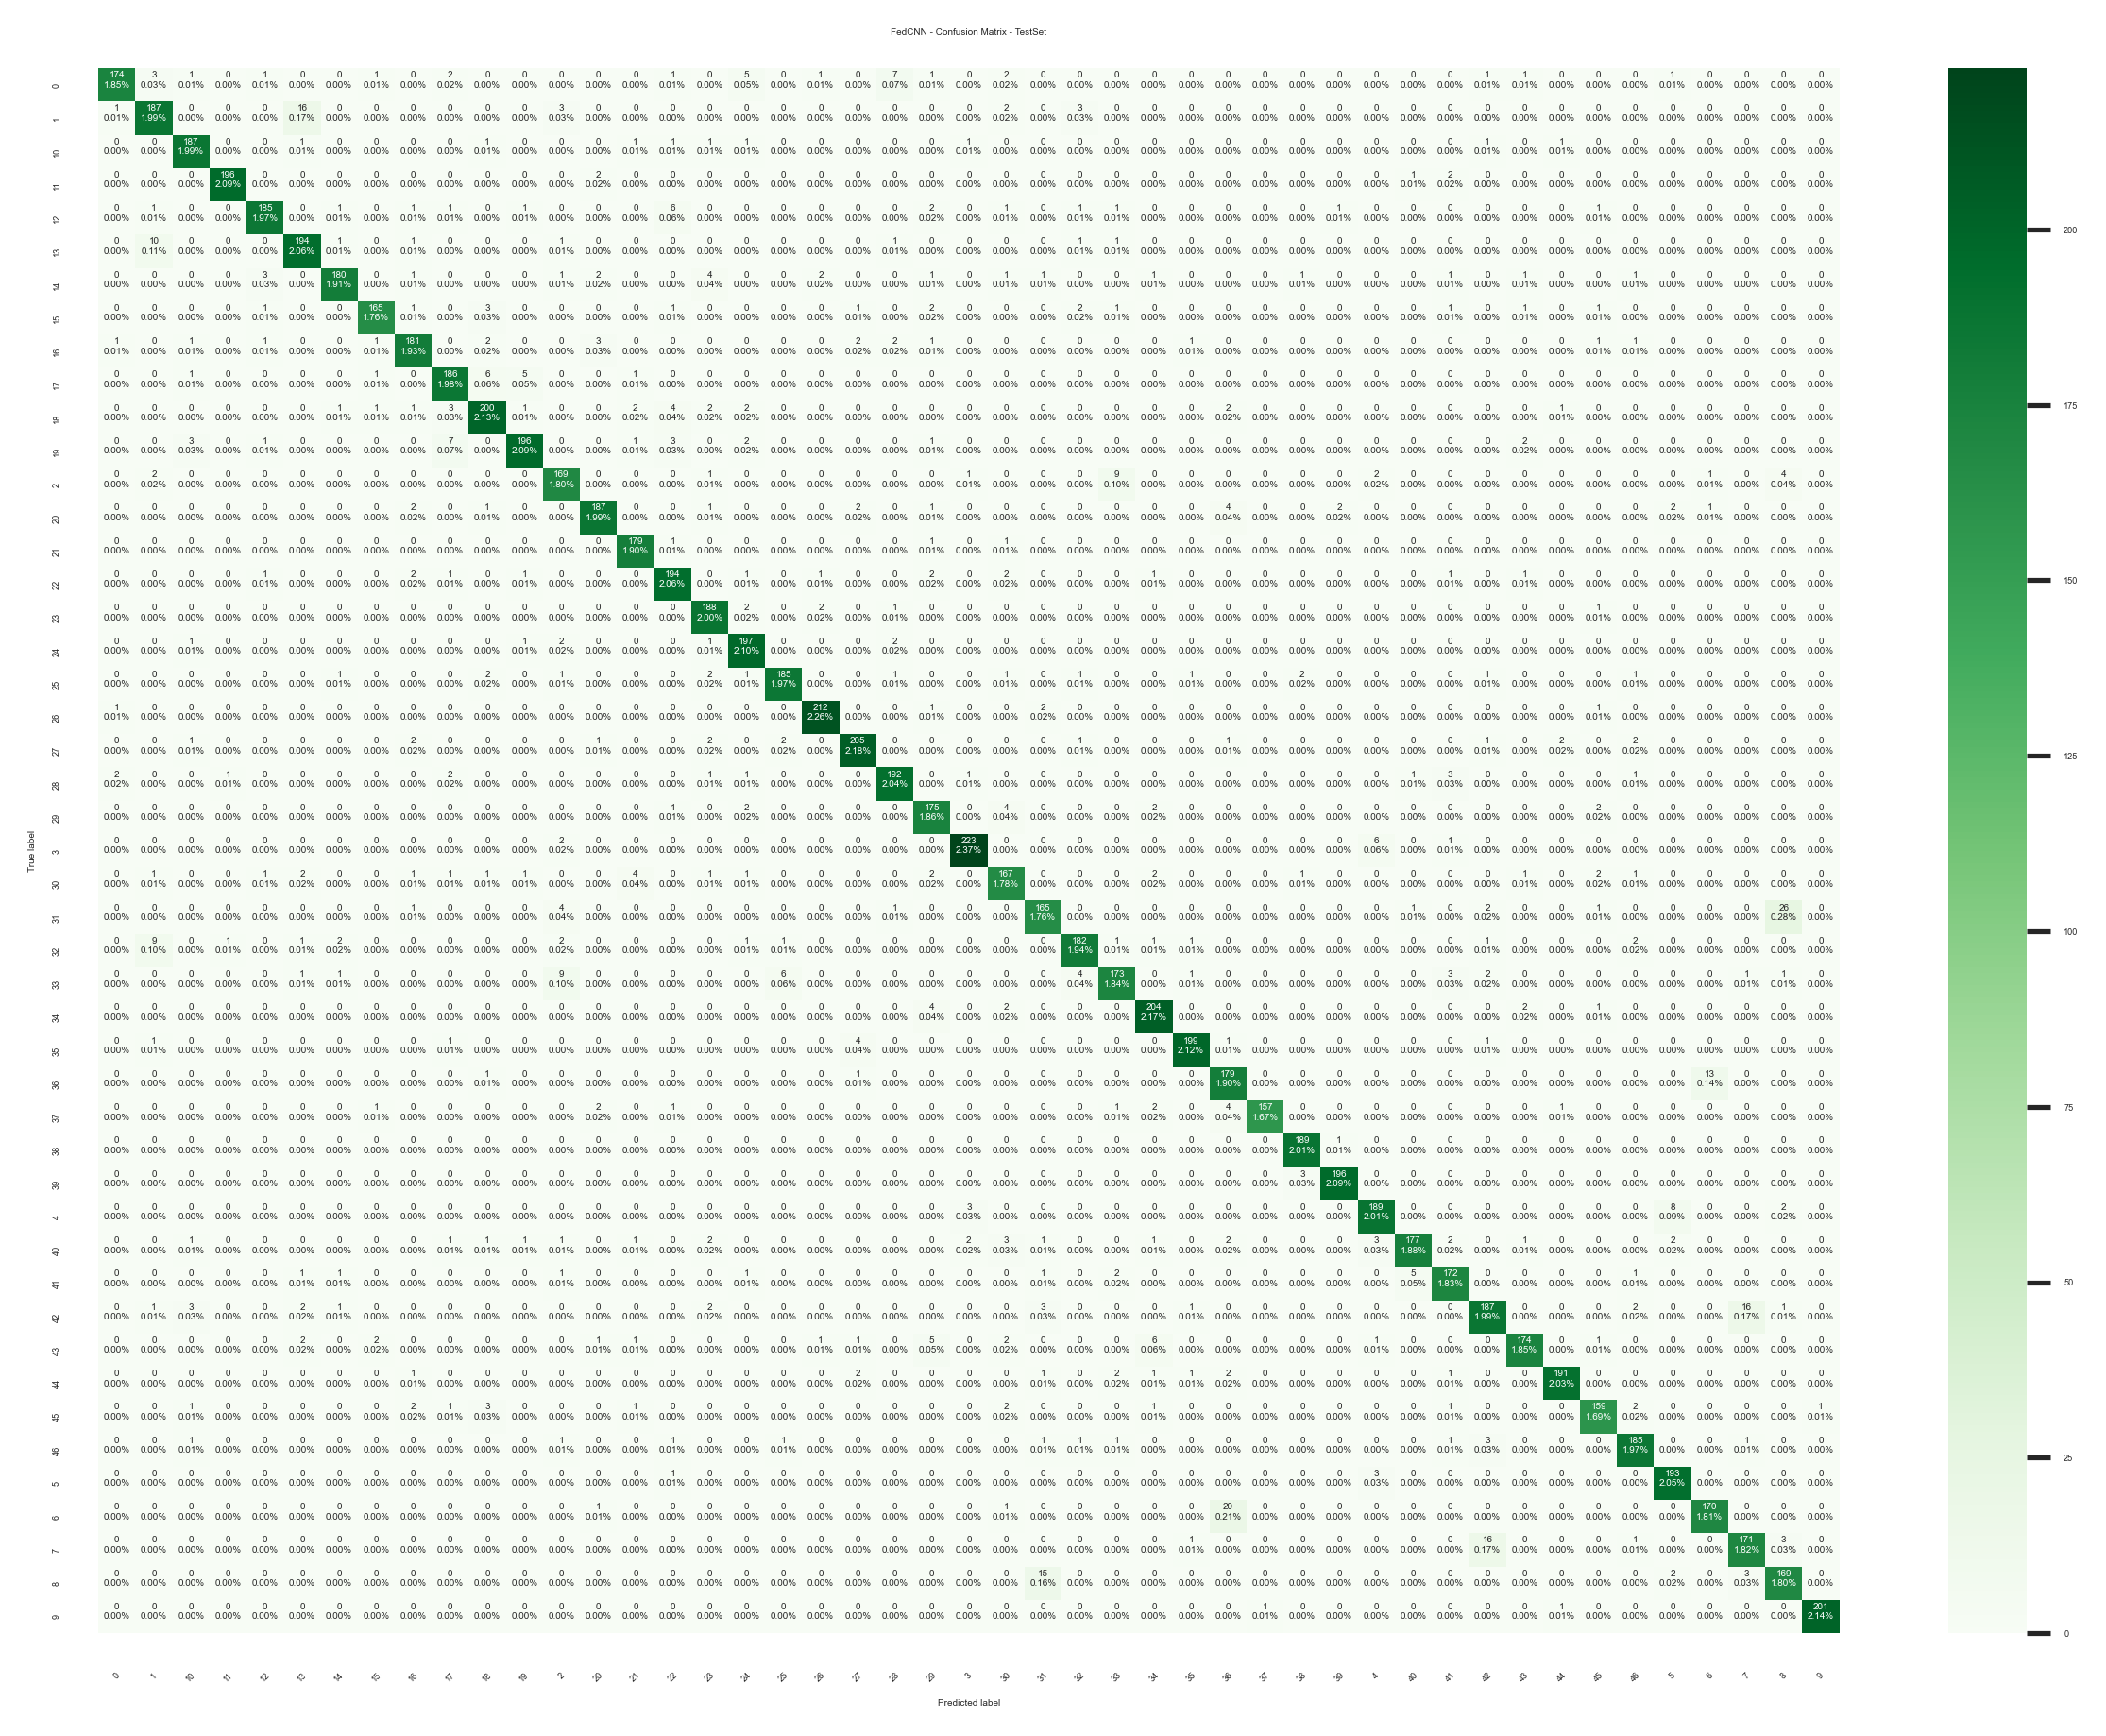

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seaborn Heatmap - Test Set
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(cm.shape[0],cm.shape[1])
# stats_text = "\n\nAccuracy={:0.5f}\nPrecision={:0.5f}\nRecall={:0.5f}\nF1 Score={:0.5f}".format(accuracy, precision, recall, f1_score)
plt.figure(figsize=(8,6), dpi=300)
sns.set(font_scale=.2)
ax = sns.heatmap(cm, annot=labels, fmt='' ,xticklabels=class_names, yticklabels=class_names, cmap="Greens")
ax.tick_params(axis='x', labelrotation=45) # rotate x-axis tick labels by 45 degrees
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("FedCNN - Confusion Matrix - TestSet\n")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix_test.pdf", dpi=300, bbox_inches='tight')
plt.show()
